In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import shutil
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.dates import DateFormatter
from dateutil.relativedelta import relativedelta

In [2]:
country_list = ['SE', 'DE', 'IT', 'DK', 'FR', 'SP']
clustering_file = 'Covid_cluster.csv'
dfs = {}

for country in country_list:
    fold_to_open = 'data/2020_' + country
    df_country = pd.read_csv(fold_to_open + '/' + clustering_file)
    df_country['date'] = pd.to_datetime(df_country['date'])
    df_country['country'] = country
    df_country = df_country.sort_values('date')
    dfs[country] = df_country

start_date = min(df['date'].min() for df in dfs.values())
end_date = max(df['date'].max() for df in dfs.values())
week_dates = [start_date + pd.DateOffset(weeks=x) for x in range((end_date - start_date).days // 7 + 1)]
max_values = df_country.groupby('chain')['pct'].max().reset_index()

for country, df_country in dfs.items():
    max_values = df_country.groupby('chain')['pct'].max().reset_index()
    max_values_filtered = max_values[max_values['pct'] > 0.2]
    df_filtered = df_country[(df_country['chain_size'] > 5) & (df_country['chain'].isin(max_values_filtered['chain']))]
    grouped_data = df_filtered.groupby('chain')

In [3]:
from scipy.optimize import curve_fit

def filterchain(country, index_chain):
    df_country = dfs[country]
    
    # Filtra i dati per Chain 
    df_filtered = df_country[df_country['chain'] == index_chain]

    sequence_data = df_filtered[['Sequence_noX', 'Sequence_pct', 'Sequence_total']].iloc[0]

    return df_filtered, sequence_data

# Definisci la sigmoid function
def sigmoid(x, a, b, L):
    return L / (1 + np.exp(-(x - b) / a))

# Definisci la sigmoid function doppia
def combined_sigmoid(x, a, b, L, a2, b2, L2):
    return L * (1 / (1 + np.exp(-(x - b) / a))) - L2 * (1 / (1 + np.exp(-(x - b2) / a2)))

def fitchain(index_chain, country, df_filtered, function, initial_parameters):
    x_data_chain = pd.to_datetime(df_filtered['date'])
    y_data_chain = df_filtered['pct']
    start_date_chain = x_data_chain.min()
    x_numeric_chain= (x_data_chain - start_date_chain).dt.days
    x_weeks_chain = (x_numeric_chain// 7)  
    x_labels_chain= start_date_chain + pd.to_timedelta(x_numeric_chain, unit='D')
    x_labels_chain = x_labels_chain.dt.strftime('%YW%U')
    popt_chain, cov = curve_fit(function, x_weeks_chain, y_data_chain, initial_parameters, maxfev=20000)
    errors = np.sqrt(np.diag(cov))
    x_fit_chain = np.linspace(x_weeks_chain.min(), x_weeks_chain.max(), 1000)
    y_fit_chain = function(x_fit_chain, *popt_chain)

    return popt_chain, errors, x_fit_chain, y_fit_chain, start_date_chain

def printparameters(index_chain, country, popt_chain, errors):
    print(f"Parametri fittati per Chain {index_chain} ({country}):")
    for i in range(len(popt_chain)):
        print(f"p{i}:", popt_chain[i], f", error p{i}:", errors[i])

In [4]:
fit_config = {
    'DE': [
        {'chains': [52], 'func': combined_sigmoid, 'p0': [10,10,1,10,10,1]},
        {'chains': [161,177], 'func': combined_sigmoid, 'p0': [10,10,1,10,10,1]},
        {'chains': [194,219], 'func': combined_sigmoid, 'p0': [10,10,1,10,10,1]},
        {'chains': [215], 'func': combined_sigmoid, 'p0': [10,10,1,10,10,1]},
        {'chains': [268,322], 'func': combined_sigmoid, 'p0': [10,10,1,10,10,1]},
        {'chains': [346,433], 'func': sigmoid, 'p0': [10,10,1]},
    ],

    'IT': [
        {'chains': [50], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [135], 'func': combined_sigmoid, 'p0': [10,10,1,10,10,1]},
        {'chains': [169,190], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [196], 'func': combined_sigmoid, 'p0': [10,10,1,10,10,1]},
        {'chains': [235,274,305], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [295,371,416], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
    ],

    'SE': [
        {'chains': [47], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [98,118], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [153], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [219,271], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [285,342], 'func': combined_sigmoid, 'p0': [1,10,1,1,10,1]},
    ],

    'FR': [
        {'chains': [54], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [161], 'func': combined_sigmoid, 'p0': [10,10,1,10,10,1]},
        {'chains': [221], 'func': combined_sigmoid, 'p0': [10,10,1,10,10,1]},
        {'chains': [263], 'func': combined_sigmoid, 'p0': [10,10,1,10,10,1]},
        {'chains': [302], 'func': combined_sigmoid, 'p0': [10,10,1,10,10,1]},
        {'chains': [335,405], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
    ],

    'SP': [
        {'chains': [50], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [117,162], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [173,204], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [198], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [240,272,297], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [295,364,407], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
    ],

    'DK': [
        {'chains': [53,100], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [105,123], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [151], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [216,257], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
        {'chains': [303,378,412], 'func': combined_sigmoid, 'p0': [1,10,1,10,10,1]},
    ]
}

In [5]:
def run_all_fits(fit_config):
    
    all_results = {}
    all_sequences = {}
    
    for country, configs in fit_config.items():
        
        all_results[country] = {}
        all_sequences[country] = {}
        
        for cfg in configs:
            
            chains = cfg['chains']
            func = cfg['func']
            p0 = cfg['p0']
            
            dfs_list = []
            
            for chain in chains:
                df_filtered, sequence_data = filterchain(country, chain)
                dfs_list.append(df_filtered)
                all_sequences[country][chain] = sequence_data['Sequence_noX']
            
            df_combined = pd.concat(dfs_list).sort_values("date")
            label = "+".join(map(str, chains))
            
            popt, errors, x_fit, y_fit, start_date = fitchain(
                label, country, df_combined, func, p0
            )
            
            all_results[country][label] = {
                "popt": popt,
                "errors": errors,
                "x_fit": x_fit,
                "y_fit": y_fit,
                "start_date": start_date
            }
    
    return all_results, all_sequences

In [6]:
results, sequences = run_all_fits(fit_config)

/home/mdavanzo/miniconda3/envs/covML/lib/python3.8/site-packages/pandas/core/series.py:726: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/mdavanzo/miniconda3/envs/covML/lib/python3.8/site-packages/pandas/core/series.py:726: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/mdavanzo/miniconda3/envs/covML/lib/python3.8/site-packages/pandas/core/series.py:726: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_2709261/564842978.py:19: RuntimeWarning: overflow encountered in exp
  return L * (1 / (1 + np.exp(-(x - b) / a))) - L2 * (1 / (1 + np.exp(-(x - b2) / a2)))


In [14]:
all_rows = []

for country, country_data in results.items():
    for label, val_dict in country_data.items():
        popt = val_dict['popt']
        errors = val_dict['errors']
        start_date = val_dict['start_date']
        x_fit = val_dict['x_fit']
        y_fit = val_dict['y_fit']

        for i, (param, err) in enumerate(zip(popt, errors)):
            all_rows.append({
                'Country': country,
                'Chain': label,
                'Parameter': f'p{i}',
                'Value': param,
                'Error': err,
                'Start_date': start_date,
            })

fit_results_df = pd.DataFrame(all_rows)

#save fit results to CSV as we will need it for next notebook 
fit_results_df.to_csv('fit_results.csv', index=False)

In [7]:
def compare_sequences(sequences, group):  
    values = []
    
    for country, chain in group:
        values.append(sequences[country][chain])
    
    all_equal = all(v == values[0] for v in values)
    
    if all_equal:
        print("Sequences are equal. These chains are the same variant.")
    else:
        print("Sequences are NOT equal. These chains are different variants.")
    
    return all_equal

In [8]:
sets = [
    [('IT', 50), ('SE', 47), ('DE', 52), ('DK', 53), ('FR', 54), ('SP', 50)],
    [('IT', 135),('SE', 118),('DE', 177), ('SP', 162)],
    [('IT', 190), ('DE', 219), ('SP', 204)],
    [('IT', 196), ('DE', 215), ('SE', 153),('SP', 198), ('DK', 151), ('FR', 221)],
    [('IT', 235), ('DE', 268), ('SE', 219),('SP', 240), ('DK', 216), ('FR', 263)],
    [('IT', 295), ('DE', 346), ('SE', 285),('SP', 295), ('DK', 303), ('FR', 335)]
]

for i, group in enumerate(sets, 1):
    print(f"\nSet {i}")
    compare_sequences(sequences, group)


Set 1
Sequences are equal. These chains are the same variant.

Set 2
Sequences are equal. These chains are the same variant.

Set 3
Sequences are equal. These chains are the same variant.

Set 4
Sequences are equal. These chains are the same variant.

Set 5
Sequences are equal. These chains are the same variant.

Set 6
Sequences are equal. These chains are the same variant.


In [9]:
variant_labels = {

    'IT': {
        '50': 'B.1.1.7 (Alpha) variant (Chain 50)',
        '135': 'B.1.617.2 (Delta) variant (Chain 135)',
        '169+190': 'B.1.1.529 (Omicron) variant (Chain 169 + 190)',
        '196': 'BA.2 (Omicron) variant (Chain 196)',
        '235+274+305': 'BA.5 (Omicron) variant (Chain 235 + 274 + 305)',
        '295+371+416': 'XBB (Omicron) variant (Chain 295 + 371 + 416)',
    },

    'DE': {
        '52': 'B.1.1.7 (Alpha) variant (Chain 52)',
        '161+177': 'B.1.617.2 (Delta) variant (Chain 161 + 177)',
        '194+219': 'B.1.1.529 (Omicron) variant (Chain 194 + 219)',
        '215': 'BA.2 (Omicron) variant (Chain 215)',
        '268+322': 'BA.2.86 (Omicron) variant (Chain 268 + 322)',
        '346+433': 'XBB.1.5 (Omicron) variant (Chain 346 + 433)',
    },

    'SP': {
        '50': 'B.1.1.7 (Alpha) variant (Chain 50)',
        '117+162': 'B.1.617.2 (Delta) (Chain 117 + 162)',
        '173+204': 'B.1.1.529 (Omicron) variant (Chain 173 + 204)',
        '198': 'BA.2 (Omicron) variant (Chain 198)',
        '240+272+297': 'BA.5 (Omicron) variant (Chain 240 + 272 + 297)',
        '295+364+407': 'XBB (Omicron) variant (Chain 295 + 364 + 407)',
    },

    'FR': {
        '54': 'B.1.1.7 (Alpha) variant (Chain 54)',
        '161': 'B.1.617.2 (Delta) (Chain 161)',
        '221': 'B.1.1.529 (Omicron) (Chain 221)',
        '263': 'BA.2 (Omicron) variant (Chain 263)',
        '302': 'BA.5 (Omicron) variant (Chain 302)',
        '335+405': 'XBB (Omicron) variant (Chain 335 + 405)',
    },

    'SE': {
        '47': 'B.1.1.7 (Alpha) variant (Chain 47)',
        '98+118': 'B.1.617.2 (Delta) (Chain 98 + 118)',
        '153': 'BA.2 (Omicron) variant (Chain 153)',
        '219+271': 'BA.5 (Omicron) variant (Chain 219 + 271)',
        '285+342': 'XBB (Omicron) variant (Chain 285 + 342)',
    },

    'DK': {
        '53+100': 'B.1.1.7 (Alpha) variant (Chain 53 + 100)',
        '151': 'BA.2 (Omicron) variant (Chain 151)',
        '216+257': 'BA.5 (Omicron) variant (Chain 216 + 257)',
        '303+378+412': 'XBB (Omicron) variant (Chain 303 + 378 + 412)'
    }
}

In [10]:
def plot_country(results, country, start_date, figure_name):
    fig, ax = plt.subplots(figsize=(20, 8))

    for label, data in results[country].items():

        # Se la chain non ha legenda, non viene plottata
        if label not in variant_labels[country]:
            continue

        x_fit = data['x_fit']
        y_fit = data['y_fit']
        start_date_chain = data['start_date']

        offset = (start_date_chain - start_date).days // 7
        legend_label = variant_labels[country][label]

        ax.plot(x_fit + offset, y_fit, label=legend_label)

    ax.set_xlabel('Weeks', fontsize=20)
    ax.set_ylabel('Percentage', fontsize=20)
    ax.set_title(f'Fitted Chains for {country}', fontsize=20)

    def week_to_date_formatter(x, pos):
        date = start_date + pd.DateOffset(weeks=int(x))
        return date.strftime('%Y-%m-%d')

    start_week = 0
    end_week = start_week + 211

    ax.set_xlim(start_week, end_week)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(week_to_date_formatter))

    plt.xticks(rotation=90, ha='right')
    ax.tick_params(labelsize=12)

    ax.legend(
        fontsize=12,
        loc='upper left',
        ncol=1
    )

    plt.tight_layout()
    plt.savefig(figure_name, dpi=300, bbox_inches='tight')
    plt.show()

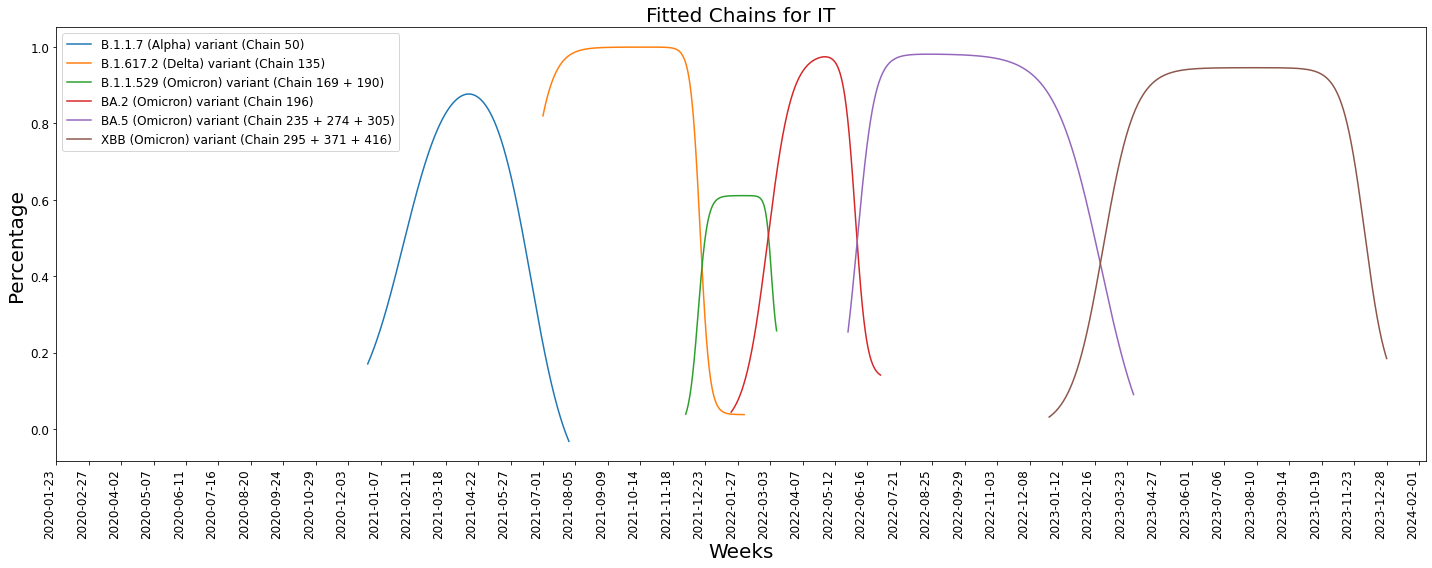

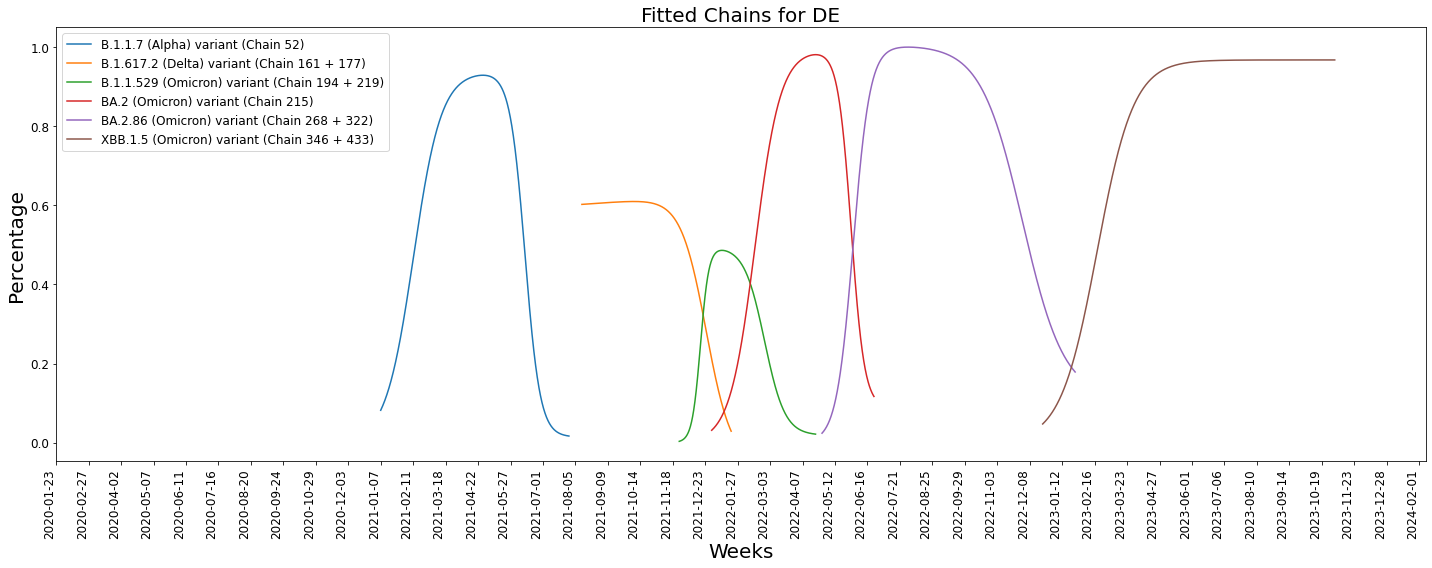

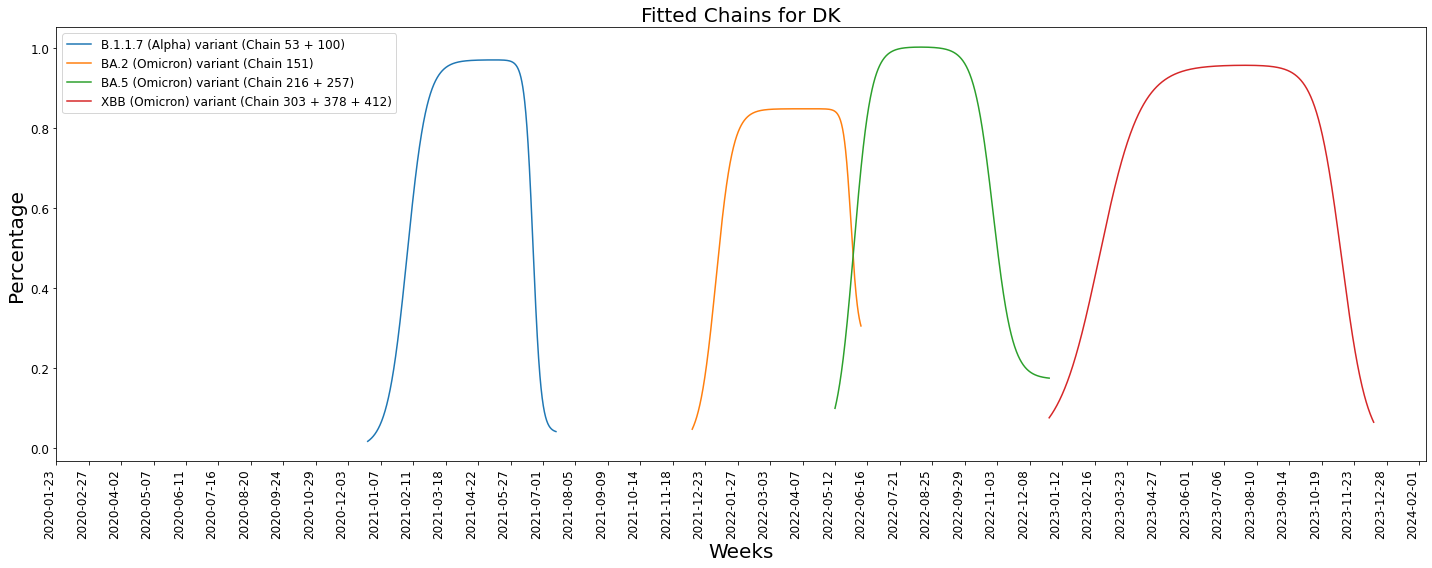

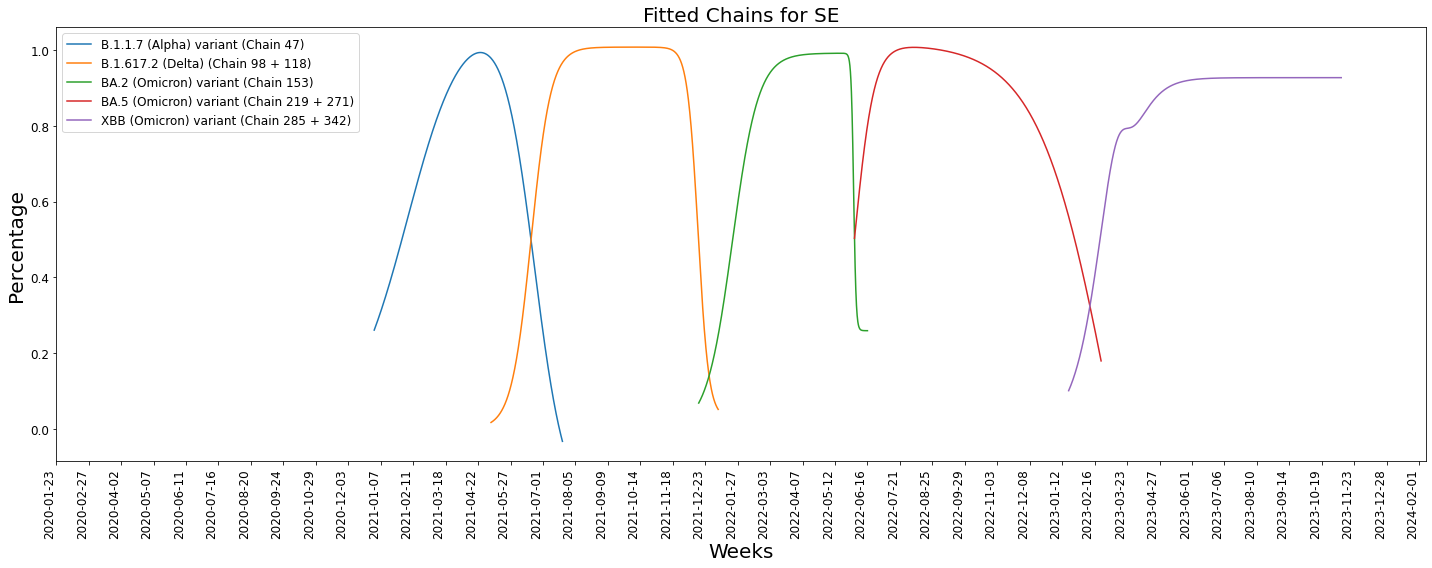

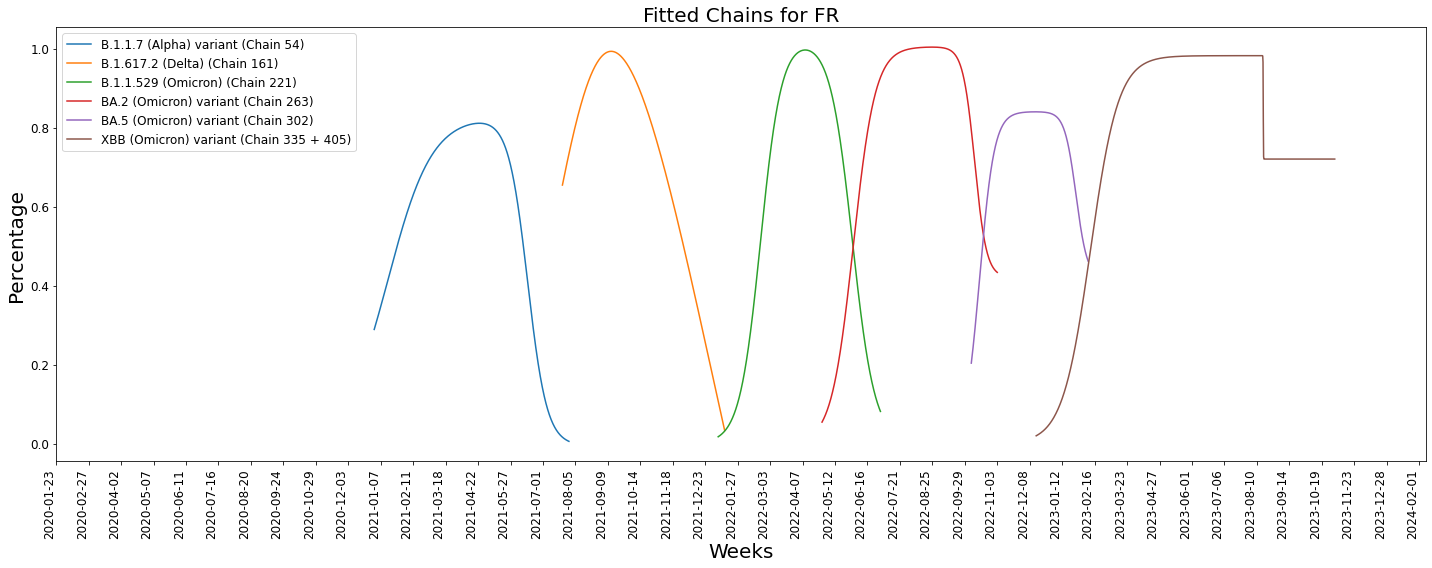

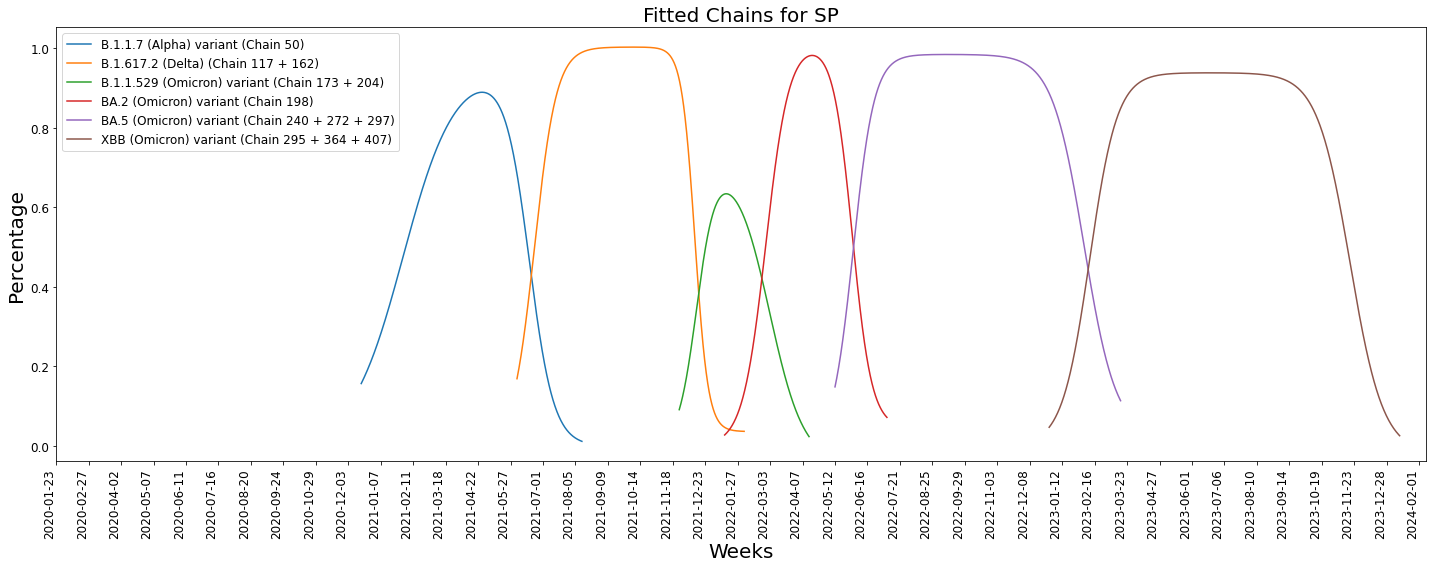

In [11]:
#obtain Figure 1 of the paper
plot_country(results, 'IT', start_date, "Figure 1 (a).pdf")
plot_country(results, 'DE', start_date, "Figure 1 (b).pdf")
plot_country(results, 'DK', start_date, "Figure 1 (c).pdf")
plot_country(results, 'SE', start_date, "Figure 1 (d).pdf")
plot_country(results, 'FR', start_date, "Figure 1 (e).pdf")
plot_country(results, 'SP', start_date, "Figure 1 (f).pdf")

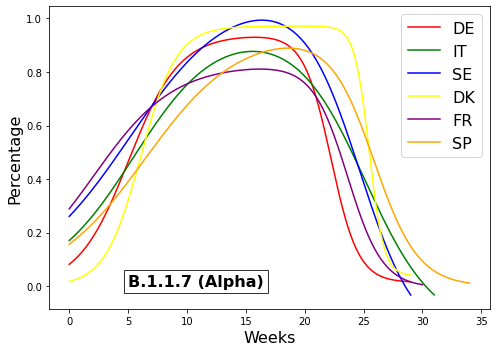

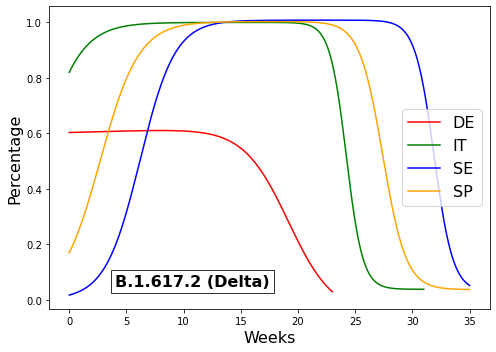

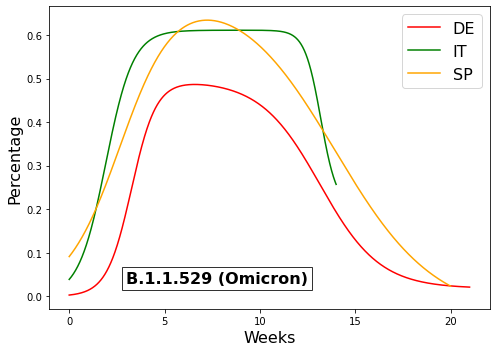

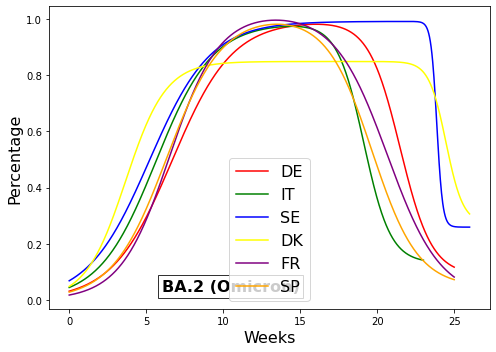

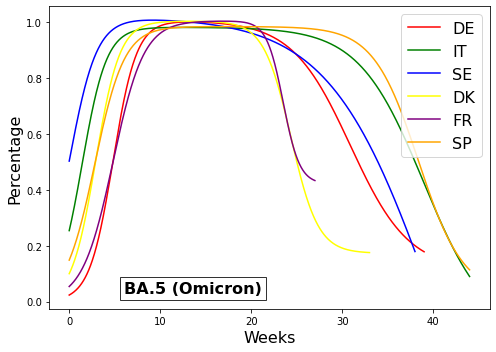

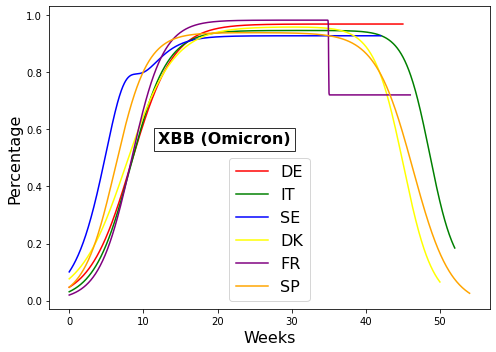

In [12]:
#function for the comparative plot of a variant (Figure S1)
def plot_variant_comparison(variant_series, variant_name, text_pos, figure_name):
    """
    variant_series: dict, key=country, value=(x_fit, y_fit)
    variant_name: str, name of the variant for the text box
    text_pos: tuple, position of the box (x, y) in the plot
    figure_name: str, name of the PDF output
    """
    colors = {
        'DE': 'red',
        'IT': 'green',
        'SE': 'blue',
        'DK': 'yellow',
        'FR': 'purple',
        'SP': 'orange'
    }

    plt.figure(figsize=(7, 5))
    
    for country, (x_fit, y_fit) in variant_series.items():
        plt.plot(x_fit, y_fit, label=country, color=colors[country])
    
    plt.xlabel('Weeks', fontsize=16)
    plt.ylabel('Percentage', fontsize=16)
    plt.grid(False)
    plt.text(text_pos[0], text_pos[1], variant_name, fontsize=16, fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))    
    plt.legend(fontsize=16)
    plt.tight_layout()
    plt.savefig(figure_name, dpi=300, bbox_inches='tight')
    plt.show()

# ---- figure S1 (a) Alpha) ----
alpha_series = {
    'DE': (results['DE']['52']['x_fit'], results['DE']['52']['y_fit']),
    'IT': (results['IT']['50']['x_fit'], results['IT']['50']['y_fit']),
    'SE': (results['SE']['47']['x_fit'], results['SE']['47']['y_fit']),
    'DK': (results['DK']['53+100']['x_fit'], results['DK']['53+100']['y_fit']),
    'FR': (results['FR']['54']['x_fit'], results['FR']['54']['y_fit']),
    'SP': (results['SP']['50']['x_fit'], results['SP']['50']['y_fit'])
}
plot_variant_comparison(alpha_series, 'B.1.1.7 (Alpha)', (5, 0), "Figure S1 (a).pdf")

# ---- figure S1 (b) Delta ----
delta_series = {
    'DE': (results['DE']['161+177']['x_fit'], results['DE']['161+177']['y_fit']),
    'IT': (results['IT']['135']['x_fit'], results['IT']['135']['y_fit']),
    'SE': (results['SE']['98+118']['x_fit'], results['SE']['98+118']['y_fit']),
    'SP': (results['SP']['117+162']['x_fit'], results['SP']['117+162']['y_fit'])
}
plot_variant_comparison(delta_series, 'B.1.617.2 (Delta)', (4, 0.05), "Figure S1 (b).pdf")

# ---- figure S1 (c) Omicron ----
omicron_series = {
    'DE': (results['DE']['194+219']['x_fit'], results['DE']['194+219']['y_fit']),
    'IT': (results['IT']['169+190']['x_fit'], results['IT']['169+190']['y_fit']),
    'SP': (results['SP']['173+204']['x_fit'], results['SP']['173+204']['y_fit'])
}
plot_variant_comparison(omicron_series, 'B.1.1.529 (Omicron)', (3, 0.03), "Figure S1 (c).pdf")

# ---- figure S1 (d) BA.2 ----
ba2_series = {
    'DE': (results['DE']['215']['x_fit'], results['DE']['215']['y_fit']),
    'IT': (results['IT']['196']['x_fit'], results['IT']['196']['y_fit']),
    'SE': (results['SE']['153']['x_fit'], results['SE']['153']['y_fit']),
    'DK': (results['DK']['151']['x_fit'], results['DK']['151']['y_fit']),
    'FR': (results['FR']['221']['x_fit'], results['FR']['221']['y_fit']),
    'SP': (results['SP']['198']['x_fit'], results['SP']['198']['y_fit'])
}
plot_variant_comparison(ba2_series, 'BA.2 (Omicron)', (6, 0.03), "Figure S1 (d).pdf")

# ---- figure S1 (e) BA.5 ----
ba5_series = {
    'DE': (results['DE']['268+322']['x_fit'], results['DE']['268+322']['y_fit']),
    'IT': (results['IT']['235+274+305']['x_fit'], results['IT']['235+274+305']['y_fit']),
    'SE': (results['SE']['219+271']['x_fit'], results['SE']['219+271']['y_fit']),
    'DK': (results['DK']['216+257']['x_fit'], results['DK']['216+257']['y_fit']),
    'FR': (results['FR']['263']['x_fit'], results['FR']['263']['y_fit']),
    'SP': (results['SP']['240+272+297']['x_fit'], results['SP']['240+272+297']['y_fit'])
}
plot_variant_comparison(ba5_series, 'BA.5 (Omicron)', (6, 0.03), "Figure S1 (e).pdf")

# ---- figure S1 (f) XBB ----
xbb_series = {
    'DE': (results['DE']['346+433']['x_fit'], results['DE']['346+433']['y_fit']),
    'IT': (results['IT']['295+371+416']['x_fit'], results['IT']['295+371+416']['y_fit']),
    'SE': (results['SE']['285+342']['x_fit'], results['SE']['285+342']['y_fit']),
    'DK': (results['DK']['303+378+412']['x_fit'], results['DK']['303+378+412']['y_fit']),
    'FR': (results['FR']['335+405']['x_fit'], results['FR']['335+405']['y_fit']),
    'SP': (results['SP']['295+364+407']['x_fit'], results['SP']['295+364+407']['y_fit'])
}
plot_variant_comparison(xbb_series, 'XBB (Omicron)', (12, 0.55), "Figure S1 (f).pdf")